<a href="https://colab.research.google.com/github/Sosswood/Machine-Learning/blob/main/Individual_Project_MovieLens_V0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#installing the required libraries. If not using Google Colab(recommended), make sure to check the requirements & versions

!pip install pandas numpy scikit-learn shap tqdm


In [2]:
# Load, examine and prepare dataset

import pandas as pd
import numpy as np
import zipfile
import io
import requests
from pathlib import Path


# Download MovieLens 1M
url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
DATA_DIR = Path("/content/ml-1m.zip")
EXTRACT_DIR = Path("/content/ml-1m")

if not DATA_DIR.exists():
    print("Downloading MovieLens 1M...")
    r = requests.get(url)
    r.raise_for_status()

    with open(DATA_DIR, "wb") as f:
        f.write(r.content)

if not EXTRACT_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(DATA_DIR) as z:
        z.extractall("/content/")

print("Dataset ready.")

# Load ratings (ml-1m format is user_id::item_id::rating::timestamp)
ratings = pd.read_csv(
    EXTRACT_DIR / "ratings.dat",
    sep="::",
    names=["user_id", "item_id", "rating", "timestamp"],
    engine="python",
    encoding="latin-1"
)

# Load movies (ml-1m format is item_id::title::genres)
items = pd.read_csv(
    EXTRACT_DIR / "movies.dat",
    sep="::",
    names=["item_id", "title", "genres"],
    engine="python",
    encoding="latin-1"
)

# Validation & diagnostics
print(ratings.head())
print(items[["item_id", "title"]].head())

assert ratings["rating"].between(1, 5).all()

print("Ratings:", len(ratings))
print("Users:", ratings["user_id"].nunique())
print("Items:", ratings["item_id"].nunique())
print("Min/Max timestamp:", ratings["timestamp"].min(), ratings["timestamp"].max())

# Sparsity
n_users = ratings["user_id"].nunique()
n_items = ratings["item_id"].nunique()
sparsity = 1 - (len(ratings) / (n_users * n_items))
print(f"Sparsity: {sparsity:.4f}")

print("Rating distribution:")
print(ratings["rating"].value_counts().sort_index())

Extracting dataset...
Dataset ready.
   user_id  item_id  rating  timestamp
0        1     1193       5  978300760
1        1      661       3  978302109
2        1      914       3  978301968
3        1     3408       4  978300275
4        1     2355       5  978824291
   item_id                               title
0        1                    Toy Story (1995)
1        2                      Jumanji (1995)
2        3             Grumpier Old Men (1995)
3        4            Waiting to Exhale (1995)
4        5  Father of the Bride Part II (1995)
Ratings: 1000209
Users: 6040
Items: 3706
Min/Max timestamp: 956703932 1046454590
Sparsity: 0.9553
Rating distribution:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


Sparsity 0.9553.  Most users didn't give a rating for most films.  Might cause issues later.

# **Exploratory Data Analysis**

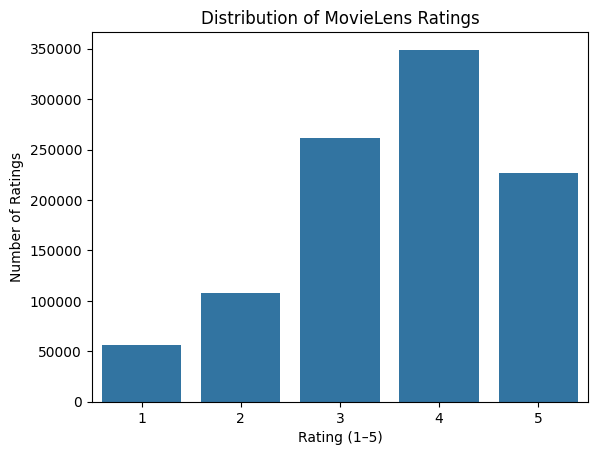

In [3]:
#Rating Disribution Chart
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=ratings, x="rating")
plt.title("Distribution of MovieLens Ratings")
plt.xlabel("Rating (1–5)")
plt.ylabel("Number of Ratings")
plt.show()

This distribution seems reasonable to me.  I'd expect people who've watched a film all the way to the end would have enjoyed it and would rank it as 3 or above.  5 is likely to be reservered for exceptional films.  A ranking of 1 or 2 may well mean that someone else made them watch it!

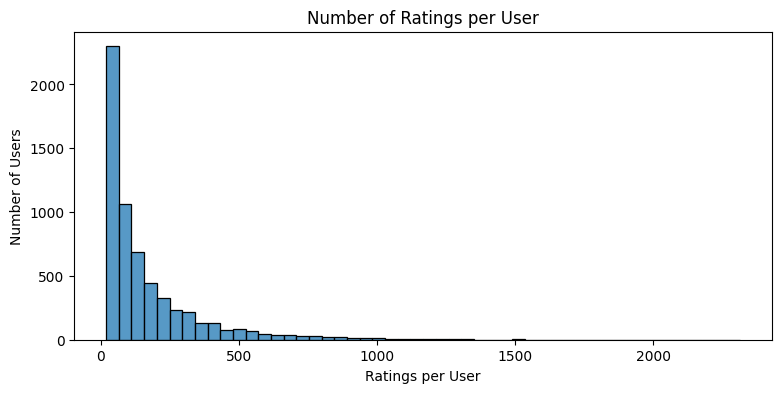

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64


In [4]:
# User Activity Distribution Chart
user_activity = ratings.groupby("user_id").size()

plt.figure(figsize=(9, 4))
sns.histplot(user_activity, bins=50)
plt.title("Number of Ratings per User")
plt.xlabel("Ratings per User")
plt.ylabel("Number of Users")
plt.show()

print(user_activity.describe())

This chart also looks more or less as I would expect.  Some users have a lot of time on their hands and are watching thousands of films.  Most users watch a few films, some have watched only a handful.   Will these two tail-ends skew our recommender?  Possibly not if we take user features into account within our model.  It could actually be helpful.

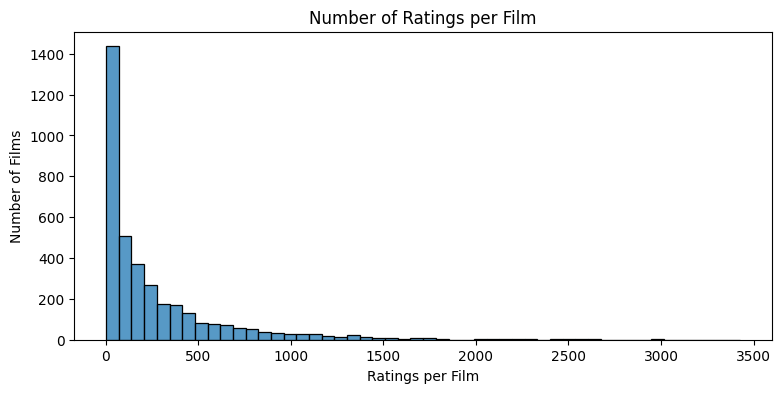

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64


In [5]:
# Film popularity distribution chart
film_activity = ratings.groupby("item_id").size()

plt.figure(figsize=(9, 4))
sns.histplot(film_activity, bins=50)
plt.title("Number of Ratings per Film")
plt.xlabel("Ratings per Film")
plt.ylabel("Number of Films")
plt.show()

print(film_activity.describe())

Some films have been watched by a lot of people.  This is expected.  The "Blockbuster" films will be watched by multiple people whilst the smaller studio releases will have received less advertising and people may have come across them more by accident than by design.  If I worked for a smaller studio, I might want to deliberately skew my recommender system to show those titles with high but fewer rankings.

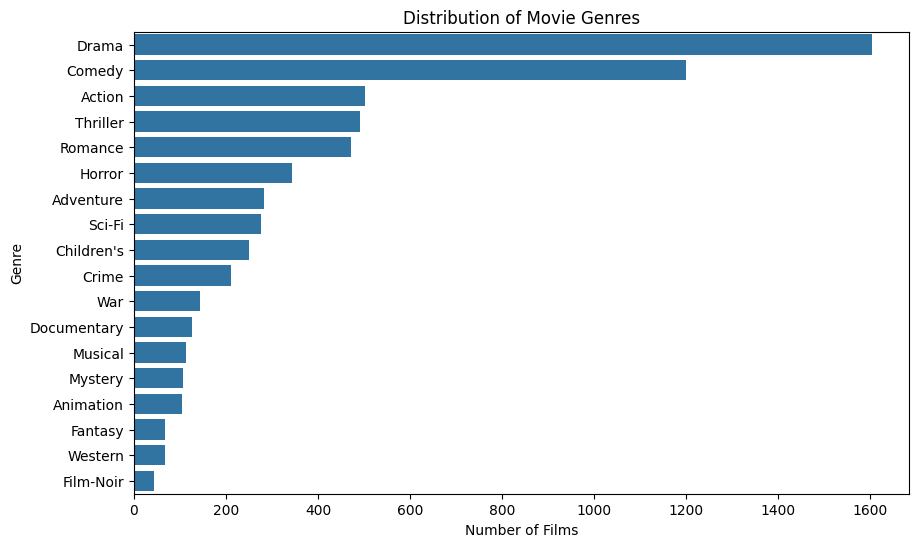

In [6]:
# Genre distribution chart
genres = items["genres"].str.split("|").explode()

genre_counts = genres.value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)
plt.title("Distribution of Movie Genres")
plt.xlabel("Number of Films")
plt.ylabel("Genre")
plt.show()

Films can belong to more than one genre, so the overall total of films per genre could be greater than the overall total of films.

Drama and Comedy are the two most highly represented genres.  I think this chart accurately represents the types of film available to be watched.  Fantasy, Western and Film-Noir are at the bottom of the list and these are certainly less popular genres overall.  If only Film-Noir "buffs" watch the Film-Noir films, does this mean that the ratings for these items could be disproportionately high compared to the ratings for the dramas, which will be watched by a much broader range of people?

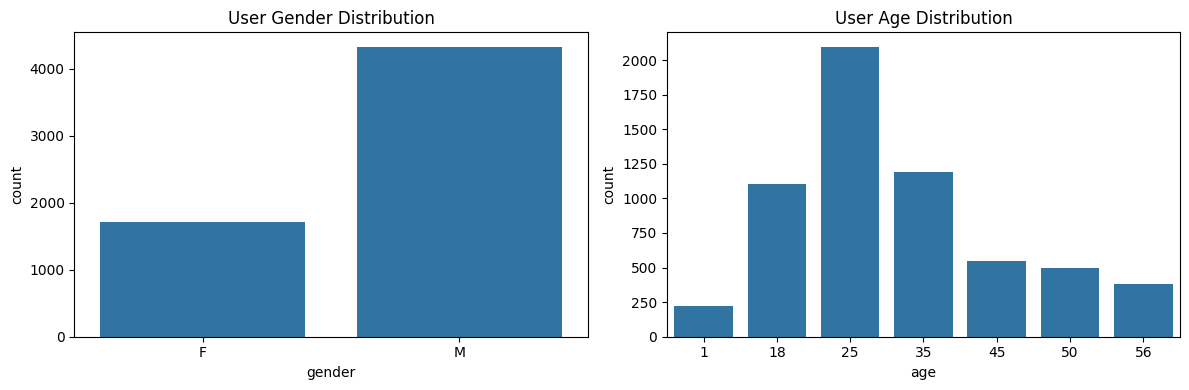

In [7]:
# Adding information about users
users = pd.read_csv(
    EXTRACT_DIR / "users.dat",
    sep="::",
    names=[
        "user_id", "gender", "age",
        "occupation", "zip_code"
    ],
    engine="python",
    encoding="latin-1"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=users, x="gender", ax=axes[0])
axes[0].set_title("User Gender Distribution")

sns.countplot(
    data=users,
    x="age",
    order=sorted(users["age"].unique()),
    ax=axes[1]
)
axes[1].set_title("User Age Distribution")

plt.tight_layout()
plt.show()

We can see that there are roughly twice as many men watching films as women.  As a feminist, I could make lots of comments about who's doing the housework and who's sitting around watching the TV, but I'll restrict myself to just commenting on the numbers.

In terms of age groups, it seems to be people in their early to mid twenties who are watching the most films.   Again - will this affect the recommender systems?  Or does that kind of information improve the recommendations if it's used correctly?

# **Traditional Model**

In [8]:
# Time-aware train/val/test split (80/10/10)
ratings_sorted = ratings.sort_values("timestamp").reset_index(drop=True)
n = len(ratings_sorted)

train = ratings_sorted.iloc[: int(0.8*n)]
val   = ratings_sorted.iloc[int(0.8*n): int(0.9*n)]
test  = ratings_sorted.iloc[int(0.9*n):]

assert train["timestamp"].max() <= val["timestamp"].min()
assert val["timestamp"].max() <= test["timestamp"].min()

print("\nSplit sizes:", len(train), len(val), len(test))

#Why time aware? In real life, you recommend based on the past, not the future.
# A random split can accidentally let the model “learn” patterns that rely on future interactions (data leakage).


Split sizes: 800167 100021 100021


In [9]:
# Build a Baseline Model.
# They are a benchmark against which more complex models can be evaluated.

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np # Import numpy if not already imported, for np.sqrt

#Baselines (sanity checks)
def eval_constant(df, c):
    y_true = df["rating"].values.astype(float)
    y_pred = np.full_like(y_true, c, dtype=float)
    # Calculate MSE first, then take the square root for RMSE
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

global_mean = train["rating"].mean()
print("\nBaseline(global mean) VAL:", eval_constant(val, global_mean))
print("Baseline(global mean) TEST:", eval_constant(test, global_mean))

# Bias baseline: r_hat = mu + b_u + b_i (with regularization)
mu = train["rating"].mean()
lambda_reg = 10.0

user_sum = train.groupby("user_id")["rating"].sum()
user_cnt = train.groupby("user_id")["rating"].count()
item_sum = train.groupby("item_id")["rating"].sum()
item_cnt = train.groupby("item_id")["rating"].count()

b_u = ((user_sum - user_cnt * mu) / (user_cnt + lambda_reg)).to_dict()
b_i = ((item_sum - item_cnt * mu) / (item_cnt + lambda_reg)).to_dict()

def predict_bias(df):
    bu = df["user_id"].map(b_u).fillna(0.0).values
    bi = df["item_id"].map(b_i).fillna(0.0).values
    return mu + bu + bi

def eval_model(df, pred_fn):
    y_true = df["rating"].values.astype(float)
    y_pred = pred_fn(df).astype(float)
    # Calculate MSE first, then take the square root for RMSE
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

print("\nBias baseline VAL:", eval_model(val, predict_bias))
print("\nBias baseline TEST:", eval_model(test, predict_bias))

# Bias account for people's different approach.
# Expected outcome: bias baseline should beat global mean baseline.


Baseline(global mean) VAL: (np.float64(1.119095769758659), 0.9365817879563894)
Baseline(global mean) TEST: (np.float64(1.0892856617652658), 0.9024856540196643)

Bias baseline VAL: (np.float64(0.9726325372647294), 0.7758681582917736)

Bias baseline TEST: (np.float64(0.945091842128301), 0.7411285794148722)


In [10]:
# Matrix Factorization assumes each user and each movie can be described by hidden features
#We don’t label these features. The model discovers them automatically.

import numpy as np
from tqdm import trange

# Define the mapping function to convert user/item IDs to contiguous indices
user_ids = sorted(ratings["user_id"].unique())
item_ids = sorted(ratings["item_id"].unique())

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}

def to_idx(df):
    u_idx = df["user_id"].map(user_to_idx).values
    m_idx = df["item_id"].map(item_to_idx).values
    r = df["rating"].values
    return u_idx, m_idx, r

#Matrix Factorization (SGD==stochastic gradient descent)

train_u, train_m, train_r = to_idx(train)
val_u,   val_m,   val_r   = to_idx(val)
test_u,  test_m,  test_r  = to_idx(test)

n_users = len(user_ids)
n_items = len(item_ids)

rng = np.random.default_rng(42)
k = 32
lr = 0.01
reg = 0.02

# --- RESTRICTING EPOCHS HERE ---
# We reduce epochs from 30 to 10 to prevent overfitting
epochs = 10

mu_mf = train_r.mean()
bu = np.zeros(n_users)
bi = np.zeros(n_items)
P = 0.1 * rng.standard_normal((n_users, k))
Q = 0.1 * rng.standard_normal((n_items, k))

def mf_predict(u_idx, m_idx):
    return mu_mf + bu[u_idx] + bi[m_idx] + np.sum(P[u_idx] * Q[m_idx], axis=1)

def rmse_vec(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

history = []
print("\nTraining MF...")
for epoch in trange(1, epochs + 1):
    perm = rng.permutation(len(train_r))
    u_sh, m_sh, r_sh = train_u[perm], train_m[perm], train_r[perm]

    for u, m, r in zip(u_sh, m_sh, r_sh):
        pred = mu_mf + bu[u] + bi[m] + P[u].dot(Q[m])
        err = r - pred

        bu[u] += lr * (err - reg * bu[u])
        bi[m] += lr * (err - reg * bi[m])

        pu = P[u].copy()
        qi = Q[m].copy()
        P[u] += lr * (err * qi - reg * pu)
        Q[m] += lr * (err * pu - reg * qi)

    train_rmse = rmse_vec(train_r, mf_predict(train_u, train_m))
    val_rmse   = rmse_vec(val_r,   mf_predict(val_u,   val_m))
    history.append((epoch, train_rmse, val_rmse))

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | train RMSE={train_rmse:.4f} | val RMSE={val_rmse:.4f}")

test_pred = mf_predict(test_u, test_m)
test_rmse = rmse_vec(test_r, test_pred)
test_mae  = float(np.mean(np.abs(test_r - test_pred)))
print("\nMF TEST RMSE:", test_rmse, " MAE:", test_mae)


Training MF...


 10%|█         | 1/10 [00:21<03:09, 21.08s/it]

Epoch 01 | train RMSE=0.9147 | val RMSE=0.9824


 50%|█████     | 5/10 [01:31<01:28, 17.70s/it]

Epoch 05 | train RMSE=0.8619 | val RMSE=0.9704


100%|██████████| 10/10 [02:55<00:00, 17.53s/it]

Epoch 10 | train RMSE=0.7756 | val RMSE=0.9660

MF TEST RMSE: 0.9187120452283569  MAE: 0.7198459473821296


It is important here to look at your results.
Training diagnostics: train RMSE vs val RMSE
If both go down → good.
BUT
If train goes down but val goes up → overfitting.
Is it the case here? Check.
If you detect overfitting, one simple fix is to stop early (fewer epochs) in your training routine.

My validation loss started levelling out/rising from around 10 epochs, so I changed the number of epochs from 30 to 10 (early stopping) and re-ran

In [11]:
# Top-N recommendations + ranking validation
#Why do we use a ranking metric? Because of what the RS do.
# They are judged on their usefulness: “Did we put the right movies near the top?”


train_items_by_user = train.groupby("user_id")["item_id"].apply(set).to_dict()
test_pos = test[test["rating"] >= 4].groupby("user_id")["item_id"].apply(set).to_dict()

all_item_idx = np.arange(n_items)

u2i = user_to_idx # Alias user_to_idx to u2i
m2i = item_to_idx # Alias item_to_idx to m2i

def ndcg_at_k(relevances, k):
    rel = relevances[:k]
    dcg = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(rel))
    ideal = sorted(relevances, reverse=True)[:k]
    idcg = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(ideal))
    return 0.0 if idcg == 0 else float(dcg / idcg)

def recommend_for_user(user_id, K=10):
    uidx = u2i[user_id]
    seen = train_items_by_user.get(user_id, set())
    seen_idx = np.array([m2i[m] for m in seen if m in m2i], dtype=int)

    u_vec = np.full(n_items, uidx, dtype=int)
    scores = mf_predict(u_vec, all_item_idx)

    scores[seen_idx] = -1e9  # filter seen items

    topk_idx = np.argpartition(-scores, K)[:K]
    topk_idx = topk_idx[np.argsort(-scores[topk_idx])]

    topk_item_ids = [item_ids[i] for i in topk_idx]
    return topk_item_ids, scores[topk_idx]

def ranking_eval(K=10, max_users=500):
    users = list(test["user_id"].unique())[:max_users]
    precs, recs, ndcgs, cover_items = [], [], [], set()

    for u in users:
        gt = test_pos.get(u, set())
        if not gt:
            continue

        recs_u, _ = recommend_for_user(u, K=K)
        cover_items.update(recs_u)

        hits = [1 if m in gt else 0 for m in recs_u]
        precs.append(np.mean(hits))
        recs.append(np.sum(hits) / len(gt))
        ndcgs.append(ndcg_at_k(hits, K))

    coverage = len(cover_items) / n_items
    return {
        "precision@k": float(np.mean(precs)) if precs else 0.0,
        "recall@k": float(np.mean(recs)) if recs else 0.0,
        "ndcg@k": float(np.mean(ndcgs)) if ndcgs else 0.0,
        "item_coverage": float(coverage),
        "users_evaluated": int(len(precs))
    }

print("\nRanking metrics:", ranking_eval(K=10))


Ranking metrics: {'precision@k': 0.10649087221095335, 'recall@k': 0.028914433682854478, 'ndcg@k': 0.28324329123996694, 'item_coverage': 0.08661629789530491, 'users_evaluated': 493}


Metrics explained:

Precision@K: among the top K recommendations, what fraction are relevant?

Recall@K: among the relevant items the user had, what fraction did we retrieve in top K?

NDCG@K: like precision but rewards correct items appearing earlier in the list (higher rank is better).

Item coverage: how many distinct items appear in recommendations across users.

Low coverage means the model recommends the same popular movies to everyone.

In [12]:
# Diagnostics: cold-start slices + popularity bias proxy
# It is important to classify the users in RS
# Users with few ratings are hard (COLD USERS): not enough data to learn a stable preference vector
# This is why we compute RMSE separately.

user_counts = train.groupby("user_id")["rating"].count()

def slice_users(min_ratings, max_ratings=None):
    if max_ratings is None:
        return set(user_counts[user_counts >= min_ratings].index)
    return set(user_counts[(user_counts >= min_ratings) & (user_counts <= max_ratings)].index)

cold_users = slice_users(1, 10)
warm_users = slice_users(50, None)

def rmse_on_user_subset(df, user_set):
    df2 = df[df["user_id"].isin(user_set)]
    if len(df2) == 0:
        return None
    u, m, r = to_idx(df2)
    pred = mf_predict(u, m)
    return rmse_vec(r, pred)

print("\nRMSE test cold users (1-10 ratings):", rmse_on_user_subset(test, cold_users))
print("RMSE test warm users (>=50 ratings):", rmse_on_user_subset(test, warm_users))

item_pop = train.groupby("item_id")["rating"].count().to_dict()

def avg_popularity_of_recs(sample_users=200, K=10):
    users = list(test["user_id"].unique())[:sample_users]
    pops = []
    for u in users:
        recs_u, _ = recommend_for_user(u, K=K)
        pops.extend([item_pop.get(m, 0) for m in recs_u])
    return float(np.mean(pops)), float(np.median(pops))

print("Avg/Median popularity of recs:", avg_popularity_of_recs())


RMSE test cold users (1-10 ratings): 0.9624690714211434
RMSE test warm users (>=50 ratings): 0.8988256586803982
Avg/Median popularity of recs: (798.592, 546.0)


In [13]:
from sklearn.linear_model import Ridge
import shap

# Explainable AI (SHAP) for MF prediction
def mf_feature_matrix(u_idx, m_idx):
    inter = P[u_idx] * Q[m_idx]  # (n, k)
    return np.column_stack([bu[u_idx], bi[m_idx], inter])

# Surrogate training sample (approximate MF behavior)
N_SAMPLE = 20000
idx = rng.choice(len(train_r), size=min(N_SAMPLE, len(train_r)), replace=False)

X_surr = mf_feature_matrix(train_u[idx], train_m[idx])
y_surr = mf_predict(train_u[idx], train_m[idx])

surr = Ridge(alpha=1.0)
surr.fit(X_surr, y_surr)

pred_check = surr.predict(X_surr)
print("\nSurrogate fidelity RMSE (surrogate vs MF):", rmse_vec(y_surr, pred_check))

# SHAP for linear surrogate
explainer = shap.LinearExplainer(surr, X_surr, feature_perturbation="interventional")
feature_names = ["user_bias", "item_bias"] + [f"latent_inter_{j}" for j in range(k)]

def explain_prediction(user_id, item_id, top_n=10):
    uidx = u2i[user_id]
    midx = m2i[item_id]

    x = mf_feature_matrix(np.array([uidx]), np.array([midx]))
    pred_mf = float(mf_predict(np.array([uidx]), np.array([midx]))[0])
    pred_surr = float(surr.predict(x)[0])

    shap_vals = explainer.shap_values(x)[0]
    base = float(explainer.expected_value)

    title = items.loc[items["item_id"] == item_id, "title"].values
    title = title[0] if len(title) else str(item_id)

    contribs = list(zip(feature_names, shap_vals))
    contribs.sort(key=lambda t: abs(t[1]), reverse=True)

    print(f"\nExplanation for: User {user_id} -> Movie {item_id} ({title})")
    print(f"MF prediction:        {pred_mf:.3f}")
    print(f"Surrogate prediction: {pred_surr:.3f}")
    print(f"SHAP base value:      {base:.3f}")
    print("Top SHAP contributions:")
    for name, val in contribs[:top_n]:
        print(f"  {name:>16}: {val:+.4f}")

    return shap_vals, x

# Example explanation on a real test row
row = test.iloc[0]
_ = explain_prediction(int(row.user_id), int(row.item_id), top_n=10)

/usr/local/lib/python3.13/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)



Surrogate fidelity RMSE (surrogate vs MF): 0.005968734978210198

Explanation for: User 24 -> Movie 468 (Englishman Who Went Up a Hill, But Came Down a Mountain, The (1995))
MF prediction:        3.214
Surrogate prediction: 3.217
SHAP base value:      3.635
Top SHAP contributions:
         item_bias: -0.3065
         user_bias: +0.0917
   latent_inter_29: -0.0439
    latent_inter_3: -0.0388
   latent_inter_10: -0.0323
   latent_inter_18: +0.0323
   latent_inter_19: +0.0251
    latent_inter_2: -0.0247
    latent_inter_0: -0.0211
   latent_inter_21: +0.0189


Matrix Factorization predicts a rating using internal parameters (biases and latent vectors), not using explicit  “features” like genre or age.
SHAP, however, explains predictions by attributing them to input features. Because MF does not naturally expose such features, we re-express each MF prediction as a feature vector built from its own components, then train a simple model to reproduce MF’s output. SHAP is applied to this simple model, allowing us to explain which parts of the MF prediction mattered most. The surrogate is a simple, interpretable model that imitates the behaviour of a more complex model so that we can explain its predictions.
The whole idea is that we can EXPLAIN the results we got with MF using a more transparent approach (==explanaible AI)


I want to add a simple UI to show this recommender system in action

In [14]:
# Install gradio
!pip install gradio -q
import gradio as gr

In [15]:
# Create a function that takes a user ID, calculates predicted ratings for films
# they haven't rated, and returns the highest-ranked movies.
# Finally, connect that function to a Gradio interface

def recommend_films(user_id, num_recs):
    # Get the recommended item IDs and their predicted rating scores
    rec_ids, scores = recommend_for_user(int(user_id), K=int(num_recs))

    # Retrieve film titles matching the recommended item IDs
    results = []
    for item_id, score in zip(rec_ids, scores):
        title_row = items.loc[items["item_id"] == item_id, "title"]
        title = title_row.values[0] if len(title_row) > 0 else f"Unknown Film (ID: {item_id})"
        results.append([title, round(float(score), 2)])

    return results

demo = gr.Interface(
    fn=recommend_films,
    inputs=[
        gr.Dropdown(
            choices=[42, 100, 250],
            label="Select User ID"
        ),
        gr.Slider(
            minimum=1,
            maximum=10,
            value=5,
            step=1,
            label="Number of recommendations"
        )
    ],
    outputs=gr.Dataframe(
        headers=["Film", "Predicted Rating"],
        label="Recommended Films"
    ),
    title="Film Recommendation System",
    description="MovieLens 1M - Matrix Factorisation"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3d7c4375a0c5a71134.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
import pandas as pd
import numpy as np

In [17]:
# Film titles
film_titles = items.set_index("item_id")["title"].to_dict()

# Film statistics from training data only
film_stats = (
    train.groupby("item_id")
    .agg(
        rating_count=("rating", "count"),
        average_rating=("rating", "mean")
    )
)

# Smoothed average rating for cold-start recommendations
# This prevents a film with just one 5-star rating
# automatically appearing at the top.

m = 10

film_stats["baseline_score"] = (
    film_stats["rating_count"] * film_stats["average_rating"]
    + m * mu
) / (film_stats["rating_count"] + m)

film_stats["title"] = film_stats.index.map(film_titles)

# Only allow users with training history
available_users = sorted(train["user_id"].unique().tolist())

In [18]:
def personalised_recommendations(user_id):

    user_id = int(user_id)

    # Use existing matrix factorisation function
    film_ids, scores = recommend_for_user(user_id, K=5)

    results = pd.DataFrame({
        "Movie": [film_titles.get(i, "Unknown") for i in film_ids],
        "Predicted Rating": np.round(scores, 2),
        "Number of Ratings": [
            item_pop.get(i, 0) for i in film_ids
        ]
    })

    return results

In [19]:
def cold_start_recommendations():

    results = (
        film_stats
        .sort_values("baseline_score", ascending=False)
        .head(5)
        .copy()
    )

    return pd.DataFrame({
        "Film": results["title"].values,
        "Baseline Score": results["baseline_score"].round(2).values,
        "Number of Ratings": results["rating_count"].values
    })

In [20]:
def compare_popularity(user_id):

    user_id = int(user_id)

    # Personalised recommendations
    personal_ids, scores = recommend_for_user(user_id, K=5)

    personal = pd.DataFrame({
        "Film": [film_titles.get(i, "Unknown") for i in personal_ids],
        "Predicted Rating": np.round(scores, 2),
        "Popularity": [item_pop.get(i, 0) for i in personal_ids]
    })

    # Most popular films not already rated in training
    seen = train_items_by_user.get(user_id, set())

    popular = (
        film_stats
        .loc[~film_stats.index.isin(seen)]
        .sort_values("rating_count", ascending=False)
        .head(5)
    )

    popular_results = pd.DataFrame({
        "Movie": popular["title"].values,
        "Popularity": popular["rating_count"].values
    })

    overlap = len(set(personal_ids) & set(popular.index))

    summary = (
        f"{overlap} of the 5 personalised recommendations "
        f"also appear in the 5 most popular unseen movies. "
        f"Average popularity of personalised recommendations: "
        f"{personal['Popularity'].mean():.1f} training ratings."
    )

    return personal, popular_results, summary

In [21]:
with gr.Blocks(title="MovieLens Recommender") as demo:

    gr.Markdown("# MovieLens Recommendation System")
    gr.Markdown(
        "Classical Machine Learning: Matrix Factorisation (SGD)"
    )

    with gr.Tab("Personalised Recommendations"):

        user1 = gr.Dropdown(
            choices=available_users,
            value=available_users[0],
            label="Select User ID"
        )

        recommend_btn = gr.Button("Recommend Films")

        personal_output = gr.Dataframe(
            label="Top 5 Recommended Films"
        )

        recommend_btn.click(
            fn=personalised_recommendations,
            inputs=user1,
            outputs=personal_output
        )

    with gr.Tab("Cold-Start Demonstration"):

        gr.Markdown(
            "A new user has no rating history. "
            "The system uses a non-personalised baseline."
        )

        cold_btn = gr.Button("Recommend for New User")

        cold_output = gr.Dataframe(
            label="Cold-Start Recommendations"
        )

        cold_btn.click(
            fn=cold_start_recommendations,
            inputs=[],
            outputs=cold_output
        )

    with gr.Tab("Popularity Bias"):

        user2 = gr.Dropdown(
            choices=available_users,
            value=available_users[0],
            label="Select User ID"
        )

        compare_btn = gr.Button("Compare Recommendations")

        personal_comparison = gr.Dataframe(
            label="Personalised Recommendations"
        )

        popular_comparison = gr.Dataframe(
            label="Most Popular Unseen Films"
        )

        comparison_summary = gr.Textbox(
            label="Popularity Comparison"
        )

        compare_btn.click(
            fn=compare_popularity,
            inputs=user2,
            outputs=[
                personal_comparison,
                popular_comparison,
                comparison_summary
            ]
        )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5921f7877d3e556d55.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Deep Learning Model**

In [22]:
# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [28]:
# Build the neural network using 32-dimensional embeddings, matching the 32
#latent factors in the traditional model.
# Inputs
user_input = keras.Input(shape=(1,), dtype="int32", name="user")
film_input = keras.Input(shape=(1,), dtype="int32", name="film")

# Embedding layers
user_embedding = layers.Embedding(
    input_dim=n_users,
    output_dim=32,
    name="user_embedding"
)(user_input)

film_embedding = layers.Embedding(
    input_dim=n_items,
    output_dim=32,
    name="film_embedding"
)(film_input)

# Flatten embeddings
user_vector = layers.Flatten()(user_embedding)
film_vector = layers.Flatten()(film_embedding)

# Combine user and movie representations
combined = layers.Concatenate()([user_vector, film_vector])

# Hidden neural network layers
x = layers.Dense(64, activation="relu")(combined)
x = layers.Dense(32, activation="relu")(x)

# Predict a rating between 1 and 5
output = layers.Dense(1, activation="sigmoid")(x)
output = layers.Rescaling(scale=4.0, offset=1.0)(output)

# Create model
ncf_model = keras.Model(
    inputs=[user_input, film_input],
    outputs=output
)

ncf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

ncf_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ film (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    193,280 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ film_embedding      │ (None, 1, 32)     │    118,592 │ film[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ film_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 1)         │          0 │ dense_5[0][0]     │
│ (Rescaling)         │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 318,145 (1.21 MB)

 Trainable params: 318,145 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train the model
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_rmse",
    patience=3,
    restore_best_weights=True,
    mode="min"
)

ncf_history = ncf_model.fit(
    [train_u, train_m],
    train_r,
    validation_data=(
        [val_u, val_m],
        val_r
    ),
    epochs=20,
    batch_size=1024,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.8824 - mae: 0.7460 - rmse: 0.9393 - val_loss: 0.9465 - val_mae: 0.7755 - val_rmse: 0.9729
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.7976 - mae: 0.7059 - rmse: 0.8931 - val_loss: 0.9397 - val_mae: 0.7730 - val_rmse: 0.9694
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.7711 - mae: 0.6934 - rmse: 0.8781 - val_loss: 0.9406 - val_mae: 0.7744 - val_rmse: 0.9699
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.7464 - mae: 0.6814 - rmse: 0.8639 - val_loss: 0.9440 - val_mae: 0.7764 - val_rmse: 0.9716
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.7260 - mae: 0.6712 - rmse: 0.8520 - val_loss: 0.9487 - val_mae: 0.7782 - val_rmse: 0.9740


Early stopping is used to monitor the validation RMSE.  It will stop if the performance doesn't improve for 3 consecutive epochs.  Unlike the traditional model, where I manually stopped the training after ten epochs.

In [25]:
# Evaluate the deep-larning model
ncf_results = ncf_model.evaluate(
    [test_u, test_m],
    test_r,
    batch_size=1024,
    return_dict=True,
    verbose=0
)

print("NCF Test RMSE:", round(ncf_results["rmse"], 4))
print("NCF Test MAE:", round(ncf_results["mae"], 4))

NCF Test RMSE: 0.9279
NCF Test MAE: 0.7285


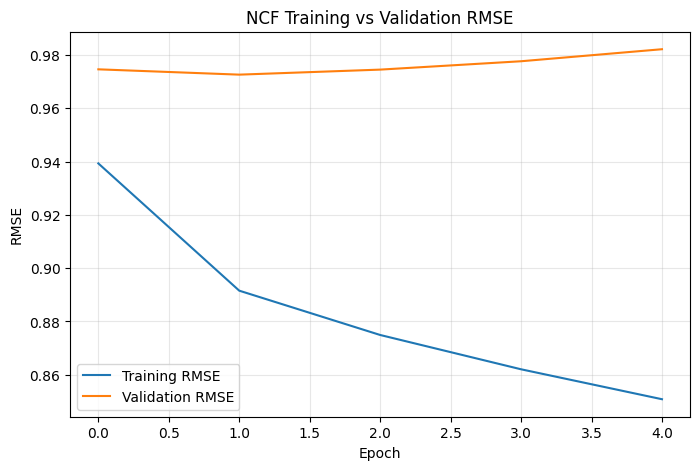

In [26]:
# Check for overfitting
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    ncf_history.history["rmse"],
    label="Training RMSE"
)

plt.plot(
    ncf_history.history["val_rmse"],
    label="Validation RMSE"
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("NCF Training vs Validation RMSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

There is a widening gap between the training and validation RMSE.  The validation RMSE holds relatively steady.  The training RMSE decreases.

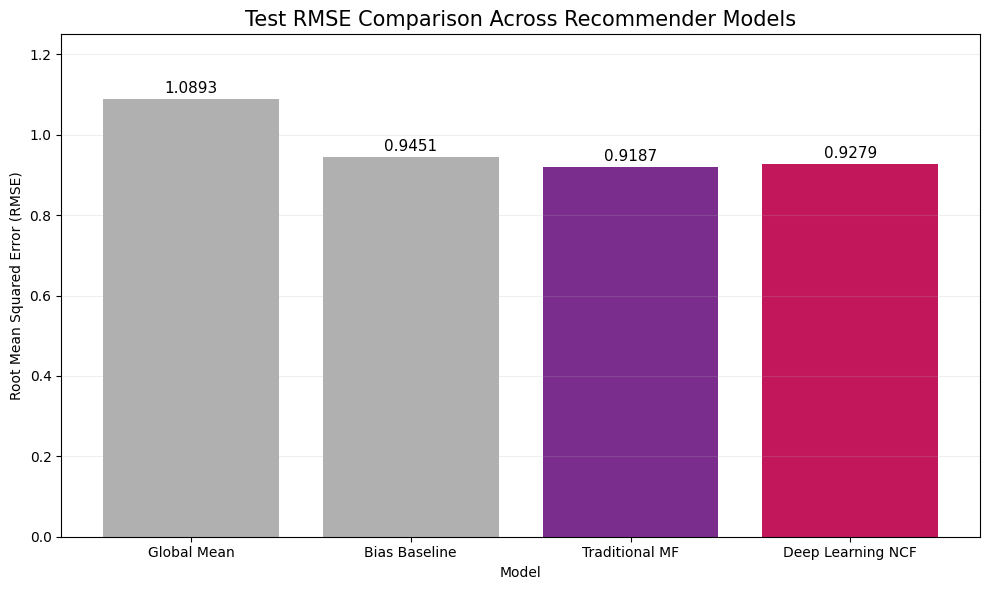

In [30]:
# Test RMSE Comparison chart
import matplotlib.pyplot as plt

# Test RMSE results from the four models
models = [
    "Global Mean",
    "Bias Baseline",
    "Traditional MF",
    "Deep Learning NCF"
]

rmse_values = [1.0893, 0.9451, 0.9187, 0.9279]

# Create chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    rmse_values,
    color=["#B0B0B0", "#B0B0B0", "#7B2D8D", "#C2185B"]
)

# Add RMSE values above bars
for bar, value in zip(bars, rmse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{value:.4f}",
        ha="center",
        fontsize=11
    )

plt.title("Test RMSE Comparison Across Recommender Models", fontsize=15)
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.xlabel("Model")

# Start y-axis at zero for a fair bar comparison
plt.ylim(0, 1.25)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

# Save a high-resolution image for PowerPoint
plt.savefig("model_rmse_comparison.png", dpi=300, bbox_inches="tight")

plt.show()


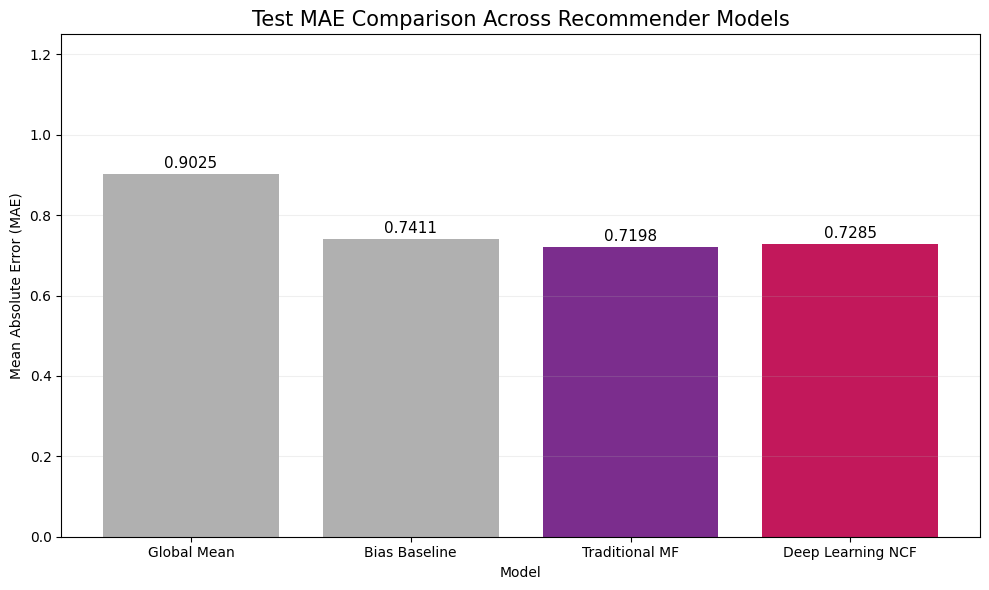

In [31]:
# Test MAE Comparison chart
import matplotlib.pyplot as plt

# Test MAE results from the four models
models = [
    "Global Mean",
    "Bias Baseline",
    "Traditional MF",
    "Deep Learning NCF"
]

mae_values = [0.9025, 0.7411, 0.7198, 0.7285]

# Create chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    mae_values,
    color=["#B0B0B0", "#B0B0B0", "#7B2D8D", "#C2185B"]
)

# Add MAE values above bars
for bar, value in zip(bars, mae_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{value:.4f}",
        ha="center",
        fontsize=11
    )

plt.title("Test MAE Comparison Across Recommender Models", fontsize=15)
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")

# Start y-axis at zero for a fair bar comparison
plt.ylim(0, 1.25)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

# Save a high-resolution image for PowerPoint
plt.savefig("model_rmse_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

As a matter of interest - which film had the most ratings, which user gave the most ratings and did that user watch the film with the most ratings?


And I'm curious, so what film got the least ratings?  And which user?  And did they watch that film - I'm guessing not.

In [34]:
# Find the film with the least ratings
least_rated_film_id = ratings['item_id'].value_counts().idxmin()
least_rated_film_title = items.loc[items['item_id'] == least_rated_film_id, 'title'].values[0]
least_rated_film_count = ratings['item_id'].value_counts().min()

# Find the user with the least ratings
least_active_user_id = ratings['user_id'].value_counts().idxmin()
least_active_user_count = ratings['user_id'].value_counts().min()

# Check if this user watched (rated) the least popular film
watched_it = ratings[(ratings['user_id'] == least_active_user_id) & (ratings['item_id'] == least_rated_film_id)]
did_watch = len(watched_it) > 0
user_rating = watched_it['rating'].values[0] if did_watch else None

print(f"Film with least ratings: {least_rated_film_title} (ID: {least_rated_film_id}) with {least_rated_film_count} ratings.")
print(f"User with least ratings: User {least_active_user_id} with {least_active_user_count} ratings.")
if did_watch:
    print(f"Yes, User {least_active_user_id} did watch '{least_rated_film_title}' and rated it {user_rating} out of 5.")
else:
    print(f"No, User {least_active_user_id} has not rated '{least_rated_film_title}'.")

Film with least ratings: Juno and Paycock (1930) (ID: 2218) with 1 ratings.
User with least ratings: User 5725 with 20 ratings.
No, User 5725 has not rated 'Juno and Paycock (1930)'.


In [35]:
# Query the users DataFrame for details on User 4169
user_info = users[users['user_id'] == 5725]
display(user_info)

,user_id,gender,age,occupation,zip_code
5724,5725,M,18,2,10018


In [37]:
# Query the users DataFrame for details on User 4169
user_info = users[users['user_id'] == 4802]
display(user_info)

,user_id,gender,age,occupation,zip_code
4801,4802,M,56,1,40601
